# 03 — Standardised Approach Loan Classification

## From a bank product to a Basel class

This is the first Standardised Approach calculation. Every synthetic loan is tested against borrower, retail, property and default fields and assigned to one Basel class.

The selected class determines the relevant CCF and risk-weight rule. Classification therefore controls the route to Standardised Approach Credit RWA.

### Classification language used below

| Term | Simple meaning |
|---|---|
| Classification rule ID | an audit label recording the rule that assigned a loan's class |
| Performing class | the class before a default override |
| Default override | replacement of performing treatment when the loan has defaulted |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display as notebook_display
from pandas.io.formats.style import Styler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from basel_credit_risk.config import load_all_config

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)


def display(*objects, **kwargs):
    # Show complete table text and wrap long descriptions in saved notebook output.
    wrapped_objects = []
    for displayed_object in objects:
        if isinstance(displayed_object, pd.DataFrame):
            displayed_object = displayed_object.style
        if isinstance(displayed_object, Styler):
            displayed_object = displayed_object.set_properties(**{
                "white-space": "normal",
                "overflow-wrap": "anywhere",
                "text-align": "left",
                "vertical-align": "top",
                "max-width": "420px",
            }).set_table_styles([
                {"selector": "table", "props": [("width", "100%"), ("table-layout", "auto")]},
                {"selector": "th", "props": [
                    ("white-space", "normal"),
                    ("overflow-wrap", "anywhere"),
                    ("word-break", "break-word"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("max-width", "180px"),
                ]},
            ], overwrite=False)
        wrapped_objects.append(displayed_object)
    return notebook_display(*wrapped_objects, **kwargs)

configs = load_all_config(ROOT / "config")
raw = pd.read_csv(ROOT / "data/generated/current_portfolio.csv.gz", low_memory=False)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)

print(f"Portfolio represented below: {len(loans):,} synthetic loan-level exposures")

Portfolio represented below: 30,000 synthetic loan-level exposures


## Loan-level classification examples

One row from each final class shows the original segment, borrower information, final class and exact rule ID. The rule ID is project lineage; it is not itself a Basel category.

In [2]:
classification_columns = [
    "exposure_id", "segment", "product_type", "borrower_type", "is_sme",
    "managed_as_retail", "retail_transactor", "regulatory_real_estate_eligible",
    "default_flag", "performing_exposure_class", "basel_exposure_class",
    "classification_rule_id",
]
classification_examples = (
    loans.sort_values(["basel_exposure_class", "exposure_id"])
    .groupby("basel_exposure_class", as_index=False)
    .first()[classification_columns]
)
display(classification_examples)

,exposure_id,segment,product_type,borrower_type,is_sme,managed_as_retail,retail_transactor,regulatory_real_estate_eligible,default_flag,performing_exposure_class,basel_exposure_class,classification_rule_id
0,EXP-0027601,bank,bank_loan,bank,False,False,False,False,0,bank,bank,CLASS_BANK_OBLIGOR
1,EXP-0009602,large_corporate,corporate_revolver,large_corporate,False,False,False,False,0,corporate,corporate,CLASS_GENERAL_CORPORATE
2,EXP-0012601,sme,sme_revolver,sme,True,False,False,False,0,corporate_sme,corporate_sme,CLASS_CORPORATE_SME
3,EXP-0000119,mortgage,mortgage,individual,False,True,False,True,1,residential_real_estate,defaulted,CLASS_DEFAULTED_OVERRIDE
4,EXP-0029401,other,other,other,False,False,False,False,0,other,other,CLASS_OTHER
5,EXP-0015601,personal_loan,personal_loan,individual,False,True,False,False,0,regulatory_retail,regulatory_retail,CLASS_REGULATORY_RETAIL
6,EXP-0000001,mortgage,mortgage,individual,False,True,False,True,0,residential_real_estate,residential_real_estate,CLASS_REGULATORY_RESIDENTIAL_REAL_ESTATE
7,EXP-0021607,credit_card,credit_card,individual,False,True,True,False,0,retail_transactor,retail_transactor,CLASS_RETAIL_TRANSACTOR
8,EXP-0021601,credit_card,credit_card,individual,False,True,False,False,0,revolving_retail,revolving_retail,CLASS_REVOLVING_RETAIL
9,EXP-0028651,sovereign,sovereign_bond,sovereign,False,False,False,False,0,sovereign,sovereign,CLASS_SOVEREIGN_OBLIGOR


The performing class remains visible even when default changes the final class. This preserves the underlying product type for IRB functions and analysis while ensuring the Standardised Approach uses the defaulted treatment.

## Portfolio after classification

The chart compares the number of loans with EAD before CRM. EAD has already been calculated in the saved engine output, but it is analysed in detail only in the next notebook.

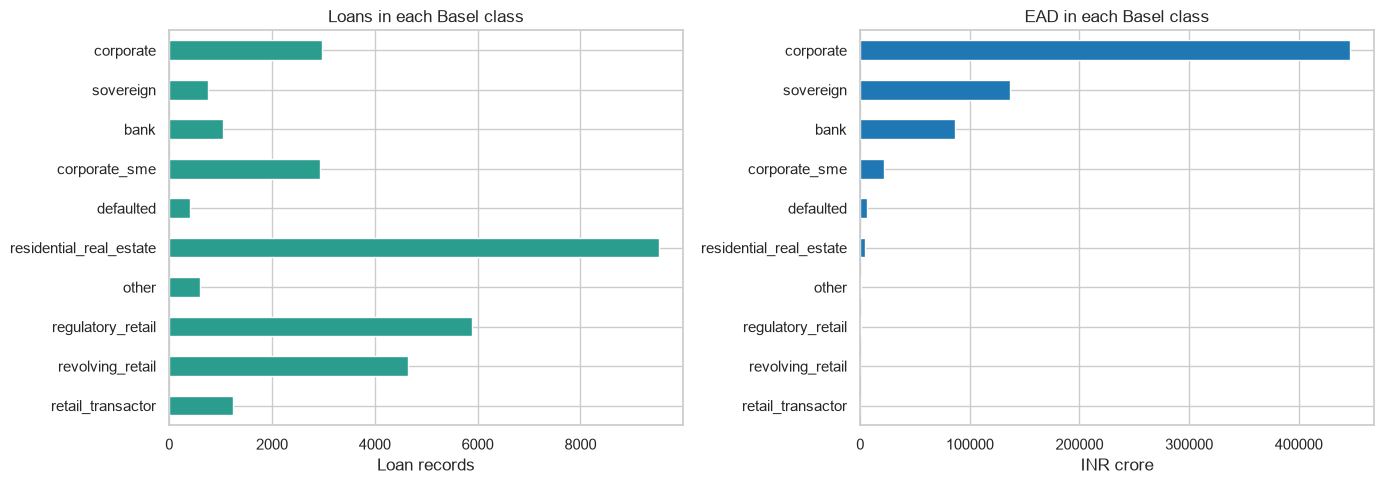

In [3]:
classified_profile = loans.groupby("basel_exposure_class").agg(
    loan_count=("exposure_id", "count"),
    ead=("ead_pre_crm", "sum"),
).sort_values("ead")
classified_profile["ead"] /= CRORE

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
classified_profile["loan_count"].plot.barh(ax=axes[0], color=COLORS[2], title="Loans in each Basel class")
classified_profile["ead"].plot.barh(ax=axes[1], color=COLORS[1], title="EAD in each Basel class")
axes[0].set_xlabel("Loan records")
axes[1].set_xlabel("INR crore")
axes[0].set_ylabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

A class with fewer loans can still dominate EAD because its facilities are larger. The Standardised Approach must therefore calculate each loan's exposure and risk weight before totals are compared.

Every loan now has a performing class, final Basel class and traceable classification rule. The next notebook calculates Standardised Approach EAD for each row.